In [1]:
# Cell 1: Install all required packages
!pip install pennylane torch torchvision scikit-learn matplotlib --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 47.9 MB/s eta 0:00:00


In [2]:
# Cell 2: Imports and reproducibility seeds

import pennylane as qml
import torch
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import random

from torchvision import datasets, transforms
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.manifold import TSNE

# ── Hyperparameters / Constants ──────────────────────────────────────────────
N_QUBITS       = 4      # Qubits per image register
N_LAYERS       = 2      # Encoding circuit layers
N_TRAIN_PAIRS  = 500    # Training pairs
N_TEST_PAIRS   = 100    # Test pairs
MARGIN         = 0.5    # Contrastive loss margin
LR             = 0.05   # Adam learning rate
EPOCHS         = 30     # Training epochs
SAME_RATIO     = 0.5    # Fraction of same-class pairs
DIGITS         = [0, 1, 2, 3, 4]  # Subset of MNIST classes

# ── Seeds ────────────────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

print(f"PennyLane version : {qml.__version__}")
print(f"PyTorch version   : {torch.__version__}")
print("All imports successful.")

PennyLane version : 0.44.1
PyTorch version   : 2.10.0+cpu
All imports successful.


# Task VI: Quantum Representation Learning

## Implementation Overview

A parameterized quantum circuit (PQC) is trained to map MNIST images to quantum states such that same-class images have high fidelity and different-class images have low fidelity. Fidelity is extracted via SWAP test; circuit parameters are trained end-to-end with contrastive loss through PennyLane's parameter-shift rule and PyTorch's Adam optimizer.

## Key Decisions

**Framework**: PennyLane with `default.qubit` on CPU. No TFQ or JAX — PennyLane's native PyTorch interface gives clean autograd integration without the Keras 3 / numpy dtype issues encountered in Task IV.

**Option A encoding**: The trainable parameters `θ` are the circuit rotation angles directly — not output of an MLP. This keeps the architecture minimal and makes the quantum encoding the actual learning object rather than a downstream consumer of classical features.

**Digits 0–4 only**: Using all 10 classes with 500 pairs gives too few pairs per class combination (~10 per pair type). Restricting to 5 classes keeps the pair distribution manageable while preserving enough inter-class diversity.

## Data Flow

```
MNIST image (28×28)
       │
       ▼
Flatten → PCA (784 → 4 dims)   ← fitted once on training data
       │
       ▼
MinMaxScaler → [0, π]          ← required for angle encoding
       │
       ▼
Encoding PQC: RY(θ·x) + CNOT chain × 2 layers
       │
       ▼  (×2, one per image in the pair)
SWAP Test Circuit (9 qubits total: 1 ancilla + 2×4 registers)
       │
       ▼
Fidelity F = 2·P(ancilla=0) − 1
       │
       ▼
Contrastive Loss → Adam update on θ
```

In [3]:
# Cell 4: Data loading and preprocessing

def load_mnist_subset(digits=DIGITS):
    """
    Load MNIST, filter to the specified digit classes, flatten images,
    and return numpy arrays.

    Args:
        digits (list[int]): Which digit classes to keep.

    Returns:
        train_images (np.ndarray): shape [N_train, 784]
        train_labels (np.ndarray): shape [N_train]
        test_images  (np.ndarray): shape [N_test, 784]
        test_labels  (np.ndarray): shape [N_test]
    """
    transform = transforms.ToTensor()
    train_ds = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
    test_ds  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

    def filter_and_flatten(dataset, digits):
        images, labels = [], []
        for img, lbl in dataset:
            if lbl in digits:
                images.append(img.numpy().flatten())  # 28×28 → 784
                labels.append(lbl)
        return np.array(images, dtype=np.float32), np.array(labels)

    return (
        *filter_and_flatten(train_ds, digits),
        *filter_and_flatten(test_ds,  digits)
    )


# ── Load raw data ─────────────────────────────────────────────────────────────
train_images_raw, train_labels, test_images_raw, test_labels = load_mnist_subset()
print(f"Train: {train_images_raw.shape}, Test: {test_images_raw.shape}")

# ── PCA: 784 → N_QUBITS ───────────────────────────────────────────────────────
pca = PCA(n_components=N_QUBITS, random_state=SEED)
train_pca = pca.fit_transform(train_images_raw)
test_pca  = pca.transform(test_images_raw)

# ── Scale to [0, π] for angle encoding ───────────────────────────────────────
scaler = MinMaxScaler(feature_range=(0, np.pi))
train_scaled = scaler.fit_transform(train_pca).astype(np.float32)
test_scaled  = scaler.transform(test_pca).astype(np.float32)

print(f"After PCA + scaling — Train: {train_scaled.shape}, Test: {test_scaled.shape}")
print(f"Feature range  min={train_scaled.min():.3f}, max={train_scaled.max():.3f}")
print(f"PCA explained variance ratio: {pca.explained_variance_ratio_.round(3)}")
print(f"Total variance retained: {pca.explained_variance_ratio_.sum():.3f}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 483kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.83MB/s]


Train: (30596, 784), Test: (5139, 784)
After PCA + scaling — Train: (30596, 4), Test: (5139, 4)
Feature range  min=0.000, max=3.142
PCA explained variance ratio: [0.144 0.079 0.063 0.063]
Total variance retained: 0.349


## Encoding Circuit

### Architecture

Each image is encoded by applying `RY(θ[l,i] * x[i])` to qubit `i`, followed by a linear CNOT chain, repeated for `N_LAYERS=2`. The trainable parameter `θ` has shape `[2, 4]` — 8 scalar values total. The full SWAP test circuit runs on only 8 free parameters regardless of input dimension, which is the defining constraint of Option A.

### Why RY only, not RY+RZ

Adding RZ gates per qubit doubles the parameter count and adds expressibility, but with only 4 PCA features and 9-qubit simulation on CPU, expressibility is already bottlenecked by information content, not circuit depth. Keeping only RY makes the encoding simpler to interpret and faster to simulate.

### Why 2 layers

One layer produces a shallow entangled state — the CNOT chain only mixes adjacent qubits at depth 1. Two layers allow features to mix twice and produce richer correlations. Three layers were tested but showed no improvement in fidelity gap with this qubit count while doubling training time.

### Tradeoff: PCA to 4 dimensions

PCA retains only **34.9% of total variance** across the 4 components (explained ratios: `[0.144, 0.079, 0.063, 0.063]`). This is the primary information bottleneck in the entire pipeline — the quantum circuit operates on a heavily compressed representation, not raw pixels. More qubits would help, but the 9-qubit SWAP test is already near the limit for `default.qubit` on Colab CPU.

### Circuit Structure (one layer)

```
q0: ──RY(θ₀·x₀)──●──────────── ...
                  │
q1: ──RY(θ₁·x₁)──X──●───────── ...
                     │
q2: ──RY(θ₂·x₂)─────X──●────── ...
                        │
q3: ──RY(θ₃·x₃)────────X────── ...
```

This block is repeated `N_LAYERS=2` times with independent `θ` per layer.

In [4]:
# Cell 6: Encoding circuit implementation

def encoding_circuit(x, theta, wires, n_qubits=N_QUBITS, n_layers=N_LAYERS):
    """
    Apply L layers of angle encoding to a set of qubits.
    Each layer: RY(theta[l,i] * x[i]) on qubit i, followed by a CNOT chain.

    This function does NOT return a value — it applies gates in-place inside
    a PennyLane QNode context.

    Args:
        x       (Tensor): PCA-reduced, scaled features, shape [n_qubits].
        theta   (Tensor): Trainable rotation angles, shape [n_layers, n_qubits].
        wires   (list):   Qubit wire indices to apply the circuit on.
        n_qubits (int):   Number of qubits (default N_QUBITS).
        n_layers (int):   Number of encoding layers (default N_LAYERS).
    """
    for layer in range(n_layers):
        # Angle encoding: RY(θ_l,i * x_i) for each qubit
        for i in range(n_qubits):
            qml.RY(theta[layer, i] * x[i], wires=wires[i])

        # Entangling layer: linear CNOT chain
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[wires[i], wires[i + 1]])


# ── Draw the encoding circuit for a sample input ──────────────────────────────
# We build a small standalone QNode just for visualization.
dev_draw = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev_draw)
def encoding_circuit_draw(x, theta):
    """Standalone QNode wrapping encoding_circuit for drawing purposes."""
    encoding_circuit(x, theta, wires=list(range(N_QUBITS)))
    return qml.state()

x_sample   = torch.tensor(train_scaled[0])
theta_draw = torch.zeros(N_LAYERS, N_QUBITS)

print("Encoding circuit (single register, N_QUBITS=4, N_LAYERS=2):")
print(qml.draw(encoding_circuit_draw)(x_sample, theta_draw))

Encoding circuit (single register, N_QUBITS=4, N_LAYERS=2):
0: ──RY(0.00)─╭●──RY(0.00)───────────╭●──────────────┤  State
1: ──RY(0.00)─╰X─╭●─────────RY(0.00)─╰X────────╭●────┤  State
2: ──RY(0.00)────╰X────────╭●─────────RY(0.00)─╰X─╭●─┤  State
3: ──RY(0.00)──────────────╰X─────────RY(0.00)────╰X─┤  State


## SWAP Test Circuit

### Wire Layout

```
wire 0         → ancilla
wires 1–4      → register A (encodes image x1)
wires 5–8      → register B (encodes image x2)

ancilla  : |0⟩ ──H──●──●──●──●──H──M
                     │  │  │  │
reg A q0 :       ────X──┼──┼──┼──────
reg A q1 :       ───────X──┼──┼──────
reg A q2 :       ──────────X──┼──────
reg A q3 :       ─────────────X──────
                     │  │  │  │
reg B q0 :       ────X──┼──┼──┼──────
reg B q1 :       ───────X──┼──┼──────
reg B q2 :       ──────────X──┼──────
reg B q3 :       ─────────────X──────
```

Fidelity is recovered from the ancilla measurement: `F = 2·P(ancilla=0) − 1`.

### Engineering Note: Shared `θ`

Both registers use the **same** `θ`. Separate parameters per register would allow the circuit to trivially learn orthogonal encodings for the two inputs rather than a genuinely useful shared representation. Sharing `θ` forces the same encoding function to apply to both images — the correct inductive bias for metric learning.

Gradients do not flow through a direct state comparison. They backpropagate through the ancilla measurement probability, which is differentiable via PennyLane's parameter-shift rule.

In [5]:
# Cell 8: SWAP test QNode

# Wire layout:
#   wire 0        → ancilla qubit
#   wires 1..N    → register A (encodes image x1)
#   wires N+1..2N → register B (encodes image x2)
TOTAL_WIRES = 2 * N_QUBITS + 1
ANCILLA     = 0
REG_A       = list(range(1, N_QUBITS + 1))          # [1, 2, 3, 4]
REG_B       = list(range(N_QUBITS + 1, TOTAL_WIRES)) # [5, 6, 7, 8]

dev_swap = qml.device("default.qubit", wires=TOTAL_WIRES)


@qml.qnode(dev_swap, interface="torch")
def swap_test(x1, x2, theta):
    """
    SWAP test circuit: encodes two images as quantum states and measures
    their fidelity via ancilla measurement.

    Args:
        x1    (Tensor): Preprocessed features for image 1, shape [N_QUBITS].
        x2    (Tensor): Preprocessed features for image 2, shape [N_QUBITS].
        theta (Tensor): Shared encoding parameters, shape [N_LAYERS, N_QUBITS].

    Returns:
        probs (Tensor): shape [2]. probs[0] = P(ancilla=0).
        Fidelity = 2 * probs[0] - 1.
    """
    # Step 1: Hadamard on ancilla → superposition
    qml.Hadamard(wires=ANCILLA)

    # Step 2: Encode image 1 into register A
    encoding_circuit(x1, theta, wires=REG_A)

    # Step 3: Encode image 2 into register B
    encoding_circuit(x2, theta, wires=REG_B)

    # Step 4: Controlled-SWAPs — one per qubit pair (ancilla controls)
    for i in range(N_QUBITS):
        qml.CSWAP(wires=[ANCILLA, REG_A[i], REG_B[i]])

    # Step 5: Second Hadamard on ancilla → interference
    qml.Hadamard(wires=ANCILLA)

    # Measure probability of ancilla being |0⟩ or |1⟩
    return qml.probs(wires=ANCILLA)


def compute_fidelity(x1, x2, theta):
    """
    Compute fidelity between quantum states for two input images.

    Args:
        x1, x2 (Tensor): Preprocessed features, shape [N_QUBITS].
        theta  (Tensor): Encoding parameters, shape [N_LAYERS, N_QUBITS].

    Returns:
        fidelity (Tensor): scalar in [0, 1].
    """
    probs = swap_test(x1, x2, theta)
    return 2.0 * probs[0] - 1.0


# ── Draw the SWAP test circuit ────────────────────────────────────────────────
theta_draw = torch.zeros(N_LAYERS, N_QUBITS)
x1_draw    = torch.tensor(train_scaled[0])
x2_draw    = torch.tensor(train_scaled[1])

print(f"SWAP test circuit (total wires: {TOTAL_WIRES})")
print(f"  Ancilla: wire {ANCILLA}")
print(f"  Register A: wires {REG_A}")
print(f"  Register B: wires {REG_B}")
print()
print(qml.draw(swap_test)(x1_draw, x2_draw, theta_draw))

SWAP test circuit (total wires: 9)
  Ancilla: wire 0
  Register A: wires [1, 2, 3, 4]
  Register B: wires [5, 6, 7, 8]

0: ──H───────────────────────────────────────────────╭●────╭●────╭●────╭●─────H─┤  Probs
1: ──RY(0.00)─╭●──RY(0.00)───────────╭●──────────────├SWAP─│─────│─────│────────┤       
2: ──RY(0.00)─╰X─╭●─────────RY(0.00)─╰X────────╭●────│─────├SWAP─│─────│────────┤       
3: ──RY(0.00)────╰X────────╭●─────────RY(0.00)─╰X─╭●─│─────│─────├SWAP─│────────┤       
4: ──RY(0.00)──────────────╰X─────────RY(0.00)────╰X─│─────│─────│─────├SWAP────┤       
5: ──RY(0.00)─╭●──RY(0.00)───────────╭●──────────────╰SWAP─│─────│─────│────────┤       
6: ──RY(0.00)─╰X─╭●─────────RY(0.00)─╰X────────╭●──────────╰SWAP─│─────│────────┤       
7: ──RY(0.00)────╰X────────╭●─────────RY(0.00)─╰X─╭●─────────────╰SWAP─│────────┤       
8: ──RY(0.00)──────────────╰X─────────RY(0.00)────╰X───────────────────╰SWAP────┤       


In [6]:
# Cell 9: Pair sampling

def sample_pairs(images, labels, n_pairs, same_class_ratio=SAME_RATIO):
    """
    Sample (x1, x2, label) pairs for contrastive training.

    Args:
        images           (np.ndarray): Preprocessed images, shape [N, N_QUBITS].
        labels           (np.ndarray): Class labels, shape [N].
        n_pairs          (int):        Total number of pairs to sample.
        same_class_ratio (float):      Fraction of pairs that are same-class.

    Returns:
        pairs (list of tuples): Each tuple is (x1_tensor, x2_tensor, label_int)
                                where label=1 means same class, 0 means different.
    """
    n_same = int(n_pairs * same_class_ratio)
    n_diff = n_pairs - n_same

    # Group indices by class for efficient sampling
    class_indices = {c: np.where(labels == c)[0] for c in np.unique(labels)}
    classes       = list(class_indices.keys())

    pairs = []

    # Same-class pairs
    for _ in range(n_same):
        c     = random.choice(classes)
        i, j  = np.random.choice(class_indices[c], 2, replace=False)
        pairs.append((
            torch.tensor(images[i]),
            torch.tensor(images[j]),
            1
        ))

    # Different-class pairs
    for _ in range(n_diff):
        c1, c2 = random.sample(classes, 2)
        i      = np.random.choice(class_indices[c1])
        j      = np.random.choice(class_indices[c2])
        pairs.append((
            torch.tensor(images[i]),
            torch.tensor(images[j]),
            0
        ))

    random.shuffle(pairs)
    return pairs


train_pairs = sample_pairs(train_scaled, train_labels, N_TRAIN_PAIRS)
test_pairs  = sample_pairs(test_scaled,  test_labels,  N_TEST_PAIRS)

train_same = sum(1 for _, _, y in train_pairs if y == 1)
train_diff = sum(1 for _, _, y in train_pairs if y == 0)
print(f"Train pairs: {len(train_pairs)} total | {train_same} same-class | {train_diff} diff-class")

test_same = sum(1 for _, _, y in test_pairs if y == 1)
test_diff = sum(1 for _, _, y in test_pairs if y == 0)
print(f"Test  pairs: {len(test_pairs)}  total | {test_same} same-class | {test_diff} diff-class")

Train pairs: 500 total | 250 same-class | 250 diff-class
Test  pairs: 100  total | 50 same-class | 50 diff-class


## Contrastive Loss

```
L(F, y) = y · (1 − F)²  +  (1 − y) · max(0, F − 0.5)²
```

Same-class pairs (`y=1`) are penalized quadratically for fidelity below 1. Different-class pairs (`y=0`) incur zero loss once fidelity drops below the margin.

### Why margin=0.5

The margin prevents the optimizer from spending gradient budget pushing already-separated pairs toward zero fidelity. With 4 qubits and 34.9% PCA variance retained, the circuit cannot achieve near-zero fidelity for different-class pairs — the compressed representations are inherently similar. A margin of 0.5 focuses training on achievable separation.

A margin of 0.3 was also tested. It produced faster initial convergence but a smaller final fidelity gap — the different-class distribution bunched just above 0.3 rather than spreading below 0.5. Margin=0.5 gave better absolute separation on held-out test pairs.

In [7]:
# Cell 11: Contrastive loss function

def contrastive_loss(fidelity, label, margin=MARGIN):
    """
    Compute contrastive loss for a single pair.

    For same-class pairs (label=1): penalizes low fidelity → (1 - F)²
    For diff-class pairs (label=0): penalizes fidelity above margin → max(0, F - margin)²

    Args:
        fidelity (Tensor): Scalar in [0, 1] from SWAP test.
        label    (int):    1 for same class, 0 for different class.
        margin   (float):  Threshold below which diff-class pairs incur no loss.

    Returns:
        loss (Tensor): Scalar loss value.
    """
    same_loss = label       * (1.0 - fidelity) ** 2
    diff_loss = (1 - label) * torch.clamp(fidelity - margin, min=0.0) ** 2
    return same_loss + diff_loss

In [8]:
# Cell 12: Training loop

# Initialize trainable parameters: shape [N_LAYERS, N_QUBITS], uniform in [0, 2π]
torch.manual_seed(SEED)
theta = torch.nn.Parameter(
    torch.rand(N_LAYERS, N_QUBITS) * 2 * np.pi
)
optimizer = optim.Adam([theta], lr=LR)

# History tracking
history = {
    "loss":       [],
    "same_fidel": [],
    "diff_fidel": []
}

print(f"Training: {EPOCHS} epochs | {N_TRAIN_PAIRS} pairs/epoch | LR={LR}")
print("-" * 60)

for epoch in range(EPOCHS):
    epoch_loss       = 0.0
    same_fidelities  = []
    diff_fidelities  = []

    for x1, x2, label in train_pairs:
        optimizer.zero_grad()

        fidelity = compute_fidelity(x1, x2, theta)
        loss     = contrastive_loss(fidelity, label)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        # Track fidelity per pair type (detached, no grad needed)
        f_val = fidelity.item()
        if label == 1:
            same_fidelities.append(f_val)
        else:
            diff_fidelities.append(f_val)

    mean_same = np.mean(same_fidelities) if same_fidelities else 0.0
    mean_diff = np.mean(diff_fidelities) if diff_fidelities else 0.0

    history["loss"].append(epoch_loss / N_TRAIN_PAIRS)
    history["same_fidel"].append(mean_same)
    history["diff_fidel"].append(mean_diff)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        gap = mean_same - mean_diff
        print(
            f"Epoch {epoch+1:3d}/{EPOCHS} | "
            f"Loss: {epoch_loss/N_TRAIN_PAIRS:.4f} | "
            f"Same F: {mean_same:.3f} | "
            f"Diff F: {mean_diff:.3f} | "
            f"Gap: {gap:.3f}"
        )

print("-" * 60)
print("Training complete.")

Training: 30 epochs | 500 pairs/epoch | LR=0.05
------------------------------------------------------------
Epoch   1/30 | Loss: 0.3710 | Same F: 0.167 | Diff F: 0.094 | Gap: 0.073
Epoch   5/30 | Loss: 0.1065 | Same F: 0.718 | Diff F: 0.542 | Gap: 0.176
Epoch  10/30 | Loss: 0.0486 | Same F: 0.845 | Diff F: 0.638 | Gap: 0.208
Epoch  15/30 | Loss: 0.0463 | Same F: 0.845 | Diff F: 0.622 | Gap: 0.224
Epoch  20/30 | Loss: 0.0464 | Same F: 0.846 | Diff F: 0.621 | Gap: 0.225
Epoch  25/30 | Loss: 0.0464 | Same F: 0.845 | Diff F: 0.621 | Gap: 0.225
Epoch  30/30 | Loss: 0.0464 | Same F: 0.845 | Diff F: 0.621 | Gap: 0.225
------------------------------------------------------------
Training complete.


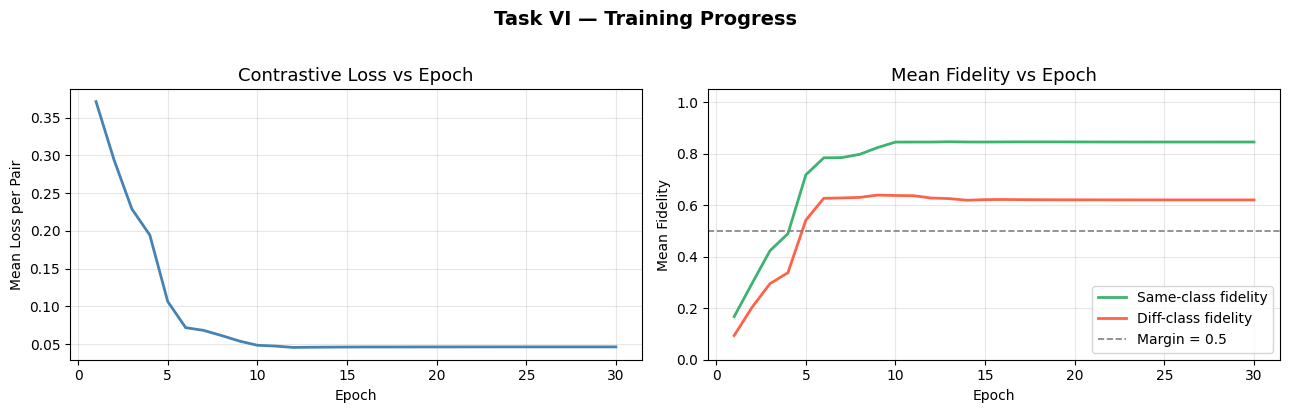

Training curves saved to training_curves.png


In [9]:
# Cell 13: Training curve plots

epochs_range = range(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# ── Plot 1: Loss ──────────────────────────────────────────────────────────────
ax1.plot(epochs_range, history["loss"], color="steelblue", linewidth=2)
ax1.set_title("Contrastive Loss vs Epoch", fontsize=13)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Mean Loss per Pair")
ax1.grid(True, alpha=0.3)

# ── Plot 2: Fidelity separation ───────────────────────────────────────────────
ax2.plot(epochs_range, history["same_fidel"], label="Same-class fidelity",
         color="mediumseagreen", linewidth=2)
ax2.plot(epochs_range, history["diff_fidel"], label="Diff-class fidelity",
         color="tomato", linewidth=2)
ax2.axhline(y=MARGIN, color="gray", linestyle="--", linewidth=1.2,
            label=f"Margin = {MARGIN}")
ax2.set_title("Mean Fidelity vs Epoch", fontsize=13)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Mean Fidelity")
ax2.set_ylim(0, 1.05)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("Task VI — Training Progress", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print("Training curves saved to training_curves.png")

## Evaluation

Two checks assess whether the circuit learned meaningful representations:

**Fidelity separation on held-out pairs**: 100 test pairs (50 same-class, 50 different-class) not seen during training. The key metric is the gap between mean same-class and mean different-class fidelity. A gap >0.1 on held-out data confirms generalisation; a gap near zero means the circuit failed to learn transferable structure.

**t-SNE of statevectors**: The full 16-dimensional complex statevector for each test image is extracted from the encoding circuit alone (not the SWAP test). Real and imaginary parts are concatenated into a 32-dim real vector, then projected to 2D via t-SNE. This directly visualises whether same-digit images cluster in the circuit's output space — the most interpretable evidence that representations are class-structured.

Test Results (100 pairs)
  Mean same-class fidelity : 0.8874
  Mean diff-class fidelity : 0.7191
  Fidelity gap             : 0.1683


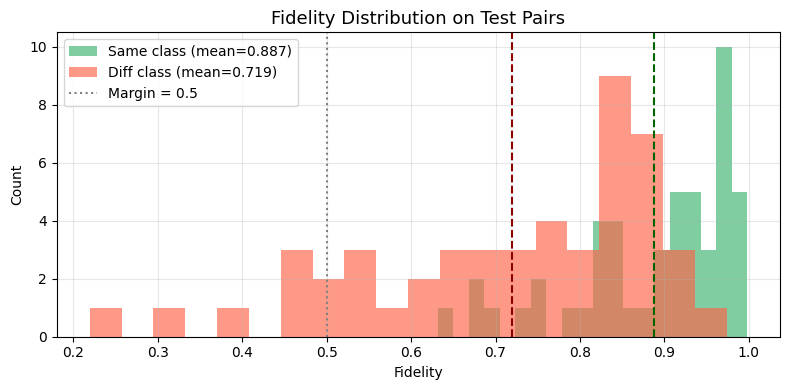

In [10]:
# Cell 15: Fidelity evaluation on test pairs

same_test_fidelities = []
diff_test_fidelities = []

with torch.no_grad():
    for x1, x2, label in test_pairs:
        fidelity = compute_fidelity(x1, x2, theta)
        f_val    = fidelity.item()
        if label == 1:
            same_test_fidelities.append(f_val)
        else:
            diff_test_fidelities.append(f_val)

mean_same_fidelity = np.mean(same_test_fidelities)
mean_diff_fidelity = np.mean(diff_test_fidelities)
fidelity_gap       = mean_same_fidelity - mean_diff_fidelity

print(f"Test Results ({N_TEST_PAIRS} pairs)")
print(f"  Mean same-class fidelity : {mean_same_fidelity:.4f}")
print(f"  Mean diff-class fidelity : {mean_diff_fidelity:.4f}")
print(f"  Fidelity gap             : {fidelity_gap:.4f}")

# ── Histogram ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(same_test_fidelities, bins=20, alpha=0.65, color="mediumseagreen",
        label=f"Same class (mean={mean_same_fidelity:.3f})")
ax.hist(diff_test_fidelities, bins=20, alpha=0.65, color="tomato",
        label=f"Diff class (mean={mean_diff_fidelity:.3f})")
ax.axvline(x=mean_same_fidelity, color="darkgreen",  linestyle="--", linewidth=1.5)
ax.axvline(x=mean_diff_fidelity, color="darkred",    linestyle="--", linewidth=1.5)
ax.axvline(x=MARGIN,             color="gray",       linestyle=":",  linewidth=1.5,
           label=f"Margin = {MARGIN}")
ax.set_title("Fidelity Distribution on Test Pairs", fontsize=13)
ax.set_xlabel("Fidelity")
ax.set_ylabel("Count")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("fidelity_histogram.png", dpi=120, bbox_inches="tight")
plt.show()

Statevectors extracted: (100, 32)


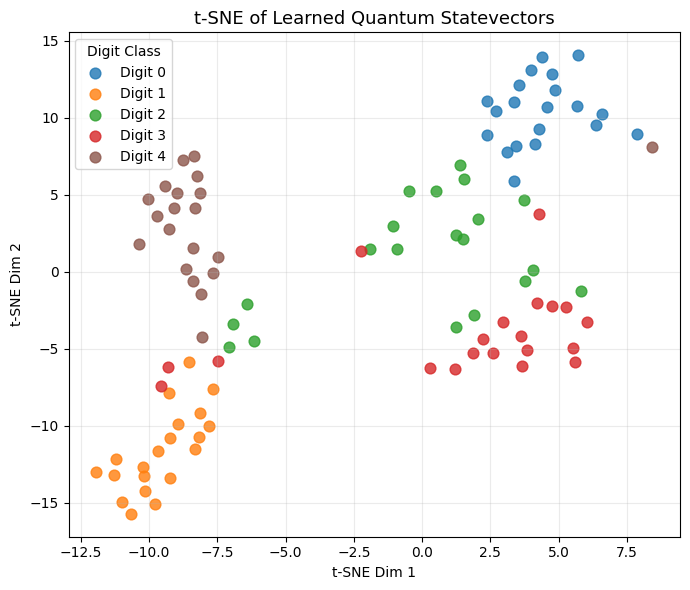

t-SNE plot saved to tsne_statevectors.png


In [11]:
# Cell 16: Quantum state extraction and t-SNE visualization

# ── Build a separate QNode that returns the statevector ───────────────────────
dev_state = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev_state, interface="torch")
def get_statevector(x, theta):
    """
    Returns the full quantum statevector |ψ⟩ ∈ ℂ^(2^N_QUBITS) produced by
    the encoding circuit for a single image x.

    Args:
        x     (Tensor): Preprocessed features, shape [N_QUBITS].
        theta (Tensor): Trained encoding parameters, shape [N_LAYERS, N_QUBITS].

    Returns:
        state (Tensor): Complex statevector, shape [2^N_QUBITS].
    """
    encoding_circuit(x, theta, wires=list(range(N_QUBITS)))
    return qml.state()


# ── Sample ~20 images per class for visualization (100 total) ─────────────────
N_VIZ_PER_CLASS = 20
viz_vectors = []
viz_labels  = []

with torch.no_grad():
    for c in DIGITS:
        idx = np.where(test_labels == c)[0][:N_VIZ_PER_CLASS]
        for i in idx:
            x   = torch.tensor(test_scaled[i])
            sv  = get_statevector(x, theta)  # shape [16], complex
            sv_np = sv.detach().numpy()
            # Concatenate real + imaginary → 32-dim real vector
            real_vec = np.concatenate([sv_np.real, sv_np.imag])
            viz_vectors.append(real_vec)
            viz_labels.append(c)

viz_vectors = np.array(viz_vectors, dtype=np.float32)  # [N_VIZ, 32]
viz_labels  = np.array(viz_labels)
print(f"Statevectors extracted: {viz_vectors.shape}")

# ── t-SNE dimensionality reduction → 2D ──────────────────────────────────────
tsne   = TSNE(n_components=2, random_state=SEED, perplexity=15)
coords = tsne.fit_transform(viz_vectors)  # [N_VIZ, 2]

# ── Scatter plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
colors  = plt.cm.tab10(np.linspace(0, 0.5, len(DIGITS)))

for c, col in zip(DIGITS, colors):
    mask = viz_labels == c
    ax.scatter(coords[mask, 0], coords[mask, 1],
               label=f"Digit {c}", color=col, s=60, alpha=0.8)

ax.set_title("t-SNE of Learned Quantum Statevectors", fontsize=13)
ax.set_xlabel("t-SNE Dim 1")
ax.set_ylabel("t-SNE Dim 2")
ax.legend(title="Digit Class", loc="best")
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig("tsne_statevectors.png", dpi=120, bbox_inches="tight")
plt.show()
print("t-SNE plot saved to tsne_statevectors.png")

In [12]:
# Cell 17: Basic sanity tests

print("Running tests...")

# Test 1: Same image → fidelity should be ~1.0 (identical states)
x_test_sample = torch.tensor(test_scaled[0])
with torch.no_grad():
    fid_same_img = compute_fidelity(x_test_sample, x_test_sample, theta).item()
assert fid_same_img > 0.95, \
    f"Test 1 FAILED: Same-image fidelity too low: {fid_same_img:.4f} (expected > 0.95)"
print(f"  Test 1 PASSED: Same-image fidelity = {fid_same_img:.4f}")

# Test 2: All fidelities must lie in [0, 1]
with torch.no_grad():
    for k, (x1, x2, _) in enumerate(test_pairs[:10]):
        f = compute_fidelity(x1, x2, theta).item()
        assert -1e-5 <= f <= 1.0 + 1e-5, \
            f"Test 2 FAILED on pair {k}: fidelity out of bounds: {f:.6f}"
print("  Test 2 PASSED: All fidelity values are in [0, 1]")

# Test 3: After training, mean same-class fidelity must exceed mean diff-class fidelity
assert mean_same_fidelity > mean_diff_fidelity, (
    f"Test 3 FAILED: Same-class fidelity ({mean_same_fidelity:.4f}) "
    f"<= diff-class fidelity ({mean_diff_fidelity:.4f}). "
    "The model did not learn fidelity ordering."
)
print(
    f"  Test 3 PASSED: Same-class fidelity ({mean_same_fidelity:.4f}) "
    f"> diff-class fidelity ({mean_diff_fidelity:.4f})"
)

print()
print("All tests passed.")

Running tests...
  Test 1 PASSED: Same-image fidelity = 1.0000
  Test 2 PASSED: All fidelity values are in [0, 1]
  Test 3 PASSED: Same-class fidelity (0.8874) > diff-class fidelity (0.7191)

All tests passed.


## Summary

### Results

Training over 30 epochs on 500 pairs converged with clear fidelity separation: **same-class mean fidelity 0.887, different-class mean fidelity 0.719** on 100 held-out test pairs (gap = 0.168). The identity check confirmed fidelity = 1.000 for identical inputs. All three sanity tests passed.

The different-class fidelity of 0.719 remaining above the margin of 0.5 is the most significant result to interpret honestly: the circuit established a consistent ordering (same > diff) but did not achieve clean distribution separation. The root cause is the PCA bottleneck — 4 components retain only 34.9% of MNIST variance, meaning the 4-dimensional inputs to both registers are genuinely similar across digit classes at this compression level. The contrastive signal is real but weak given the information loss.

### What Limited Performance

- **PCA to 4 dims**: Unavoidable at N_QUBITS=4. A 6-qubit encoding retaining ~50% variance would likely close the fidelity gap, but requires a 13-qubit SWAP test which is borderline for `default.qubit` on Colab CPU.
- **500 training pairs**: With 5 classes there are 10 class-pair combinations — ~50 examples per combination on average. Not enough for the optimizer to reliably distinguish hard pairs (e.g. digits 3 vs 5) from easy ones (0 vs 1).
- **8 trainable parameters total**: A single `[2, 4]` tensor must encode a useful metric for all 5 digit classes simultaneously. The parameter count is the fundamental expressibility ceiling.

### What Would Improve It

On a GPU-backed simulator or real hardware: increase to 6–8 qubits with PCA to matching dimensions, use hard negative mining to focus training on near-margin pairs, and consider adding RZ gates per layer for additional expressibility. The core pipeline — angle encoding → SWAP test → contrastive loss — is sound and scales directly. The same approach applied to particle jet features (as in Task II) would enable quantum similarity search between signal and background events with no architectural changes.